In [68]:
pip install squarify

In [70]:
# -------------------------Import neccessary lib----------------------------- #
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from seaborn import FacetGrid
from scipy import stats
import squarify

In [4]:
sns.set_theme(style='whitegrid', palette='colorblind')

## EDA

In [24]:
df = pd.read_csv("car_prices_extended_eda.csv")

In [5]:
makeNo = df['make'].nunique()
makeNo

53

In [6]:
make_count = df['make'].value_counts()
state_count = df['state'].value_counts()

print(f"Number of manufacturers : \n {make_count}")
print(f"Number of states : \n {state_count}")

Number of manufacturers : 
 make
Ford             81013
Chevrolet        54150
Nissan           44043
Toyota           35313
Dodge            27181
Honda            24781
Hyundai          18659
BMW              17509
Kia              15828
Chrysler         15133
Infiniti         14011
Mercedes-Benz    14008
Jeep             12735
Volkswagen       10780
Lexus            10409
GMC               9217
Mazda             6930
Cadillac          6315
Lincoln           4926
Audi              4802
Acura             4503
Buick             4470
Subaru            4369
Ram               4044
Pontiac           4018
Mitsubishi        3661
Volvo             3082
MINI              2946
Saturn            2570
Mercury           1571
Scion             1545
Land Rover        1322
Jaguar            1257
Porsche           1157
Suzuki             977
HUMMER             768
FIAT               725
Saab               416
smart              343
Oldsmobile         318
Isuzu              179
Maserati           109
B

In [28]:
print(df['odometer'].describe())

count    472325.000000
mean      66701.732040
std       51939.586894
min           1.000000
25%       28137.000000
50%       51085.000000
75%       96590.000000
max      999999.000000
Name: odometer, dtype: float64


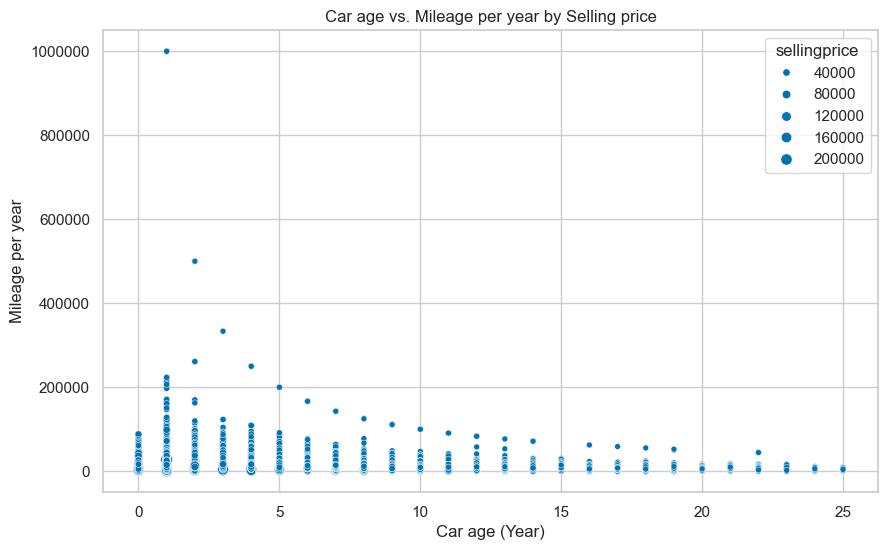

In [86]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='car_age', y='mileage_per_year', size='sellingprice', ax=ax)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
plt.title('Car age vs. Mileage per year by Selling price')
plt.xlabel('Car age (Year)')
plt.ylabel('Mileage per year')
plt.show()

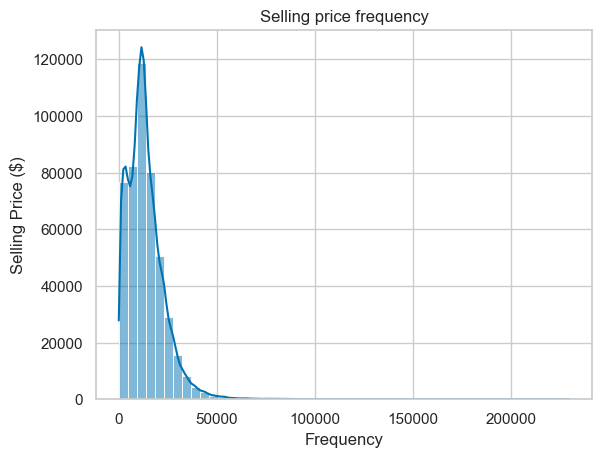

count    472325.000000
mean      13690.512058
std        9613.033738
min           1.000000
25%        7200.000000
50%       12200.000000
75%       18200.000000
max      230000.000000
Name: sellingprice, dtype: float64


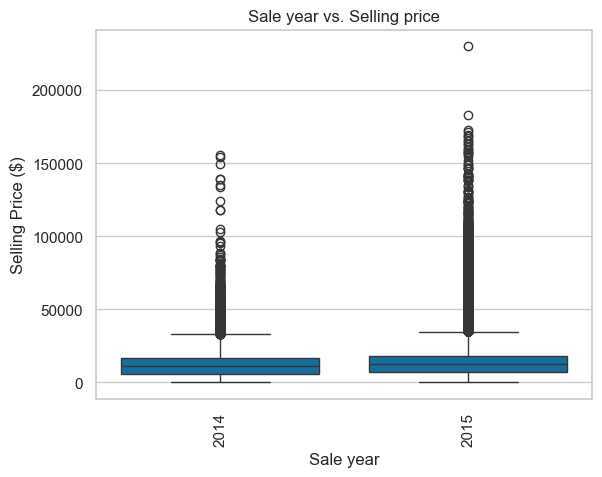

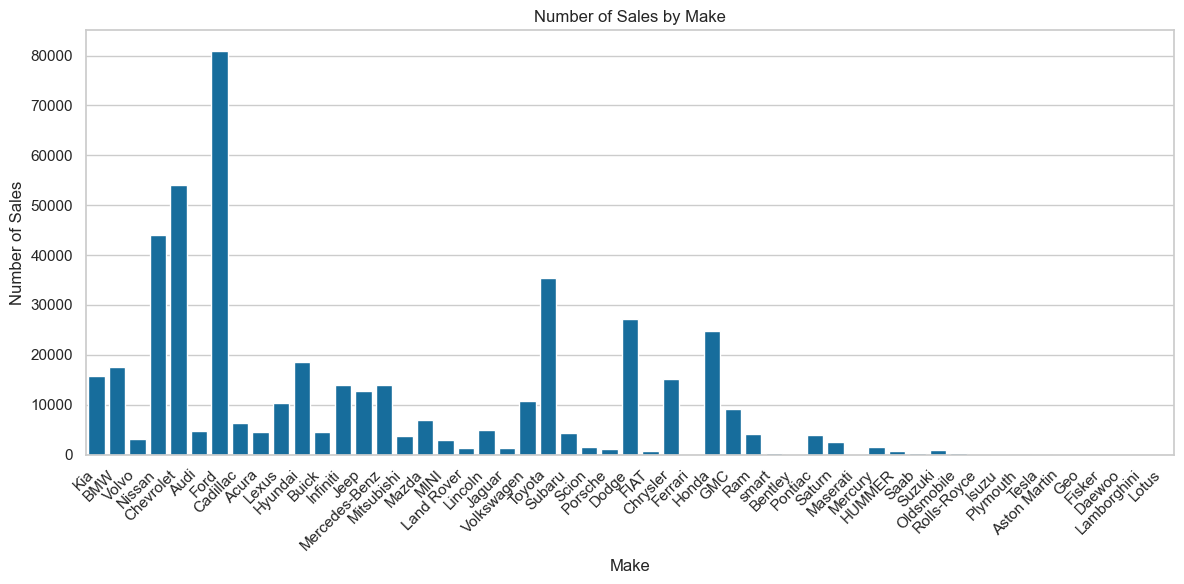

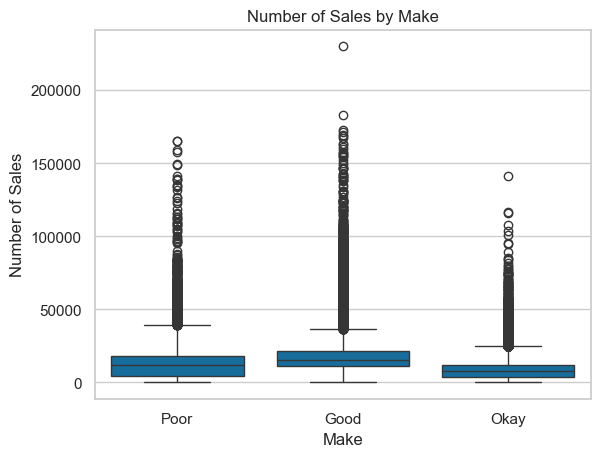

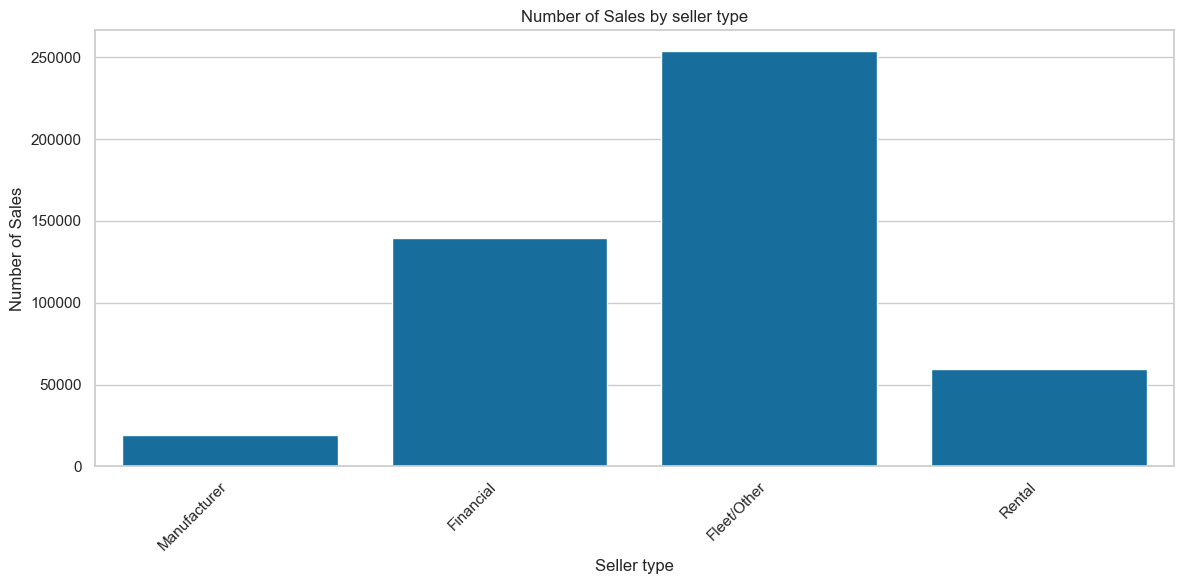

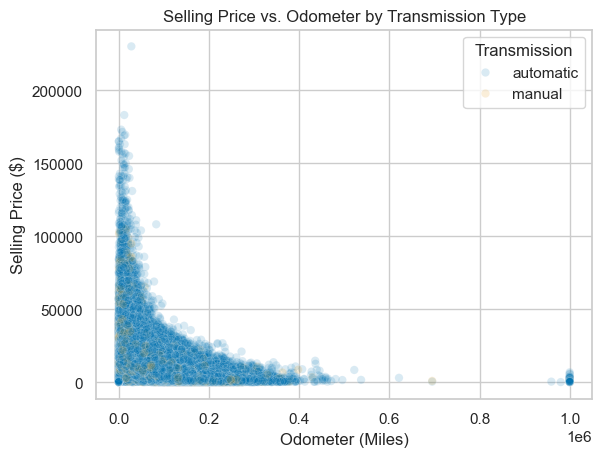

C:\Users\Alpha\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


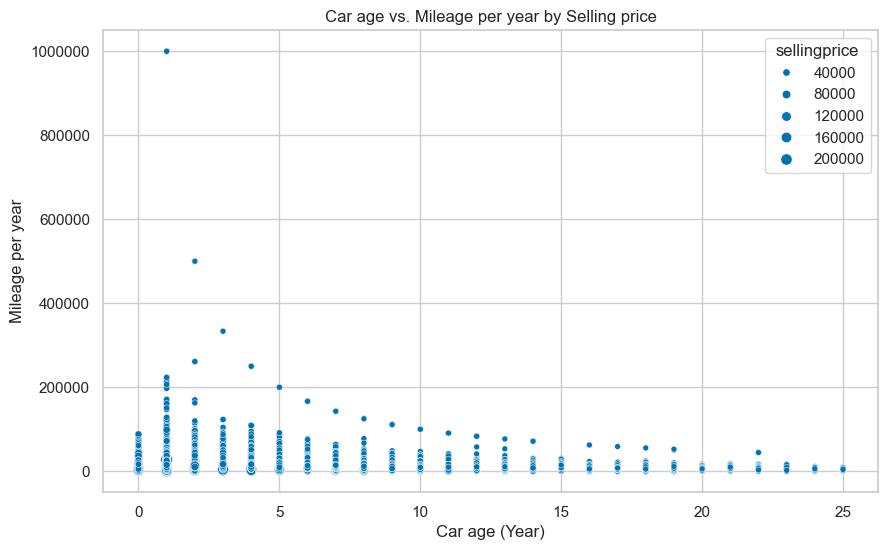

C:\Users\Alpha\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


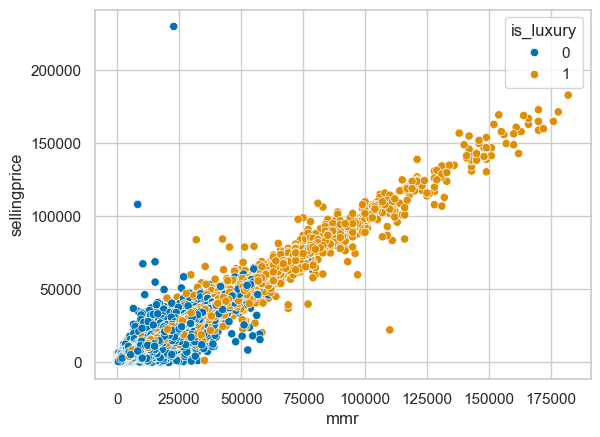

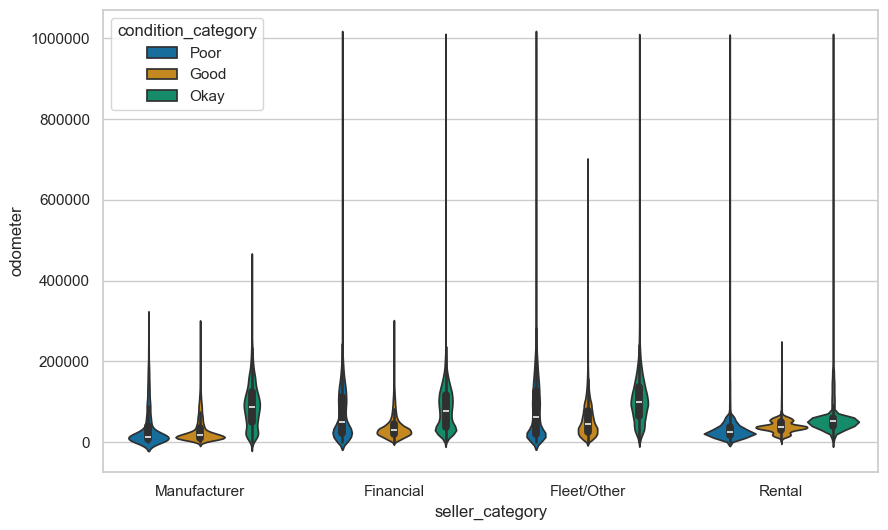

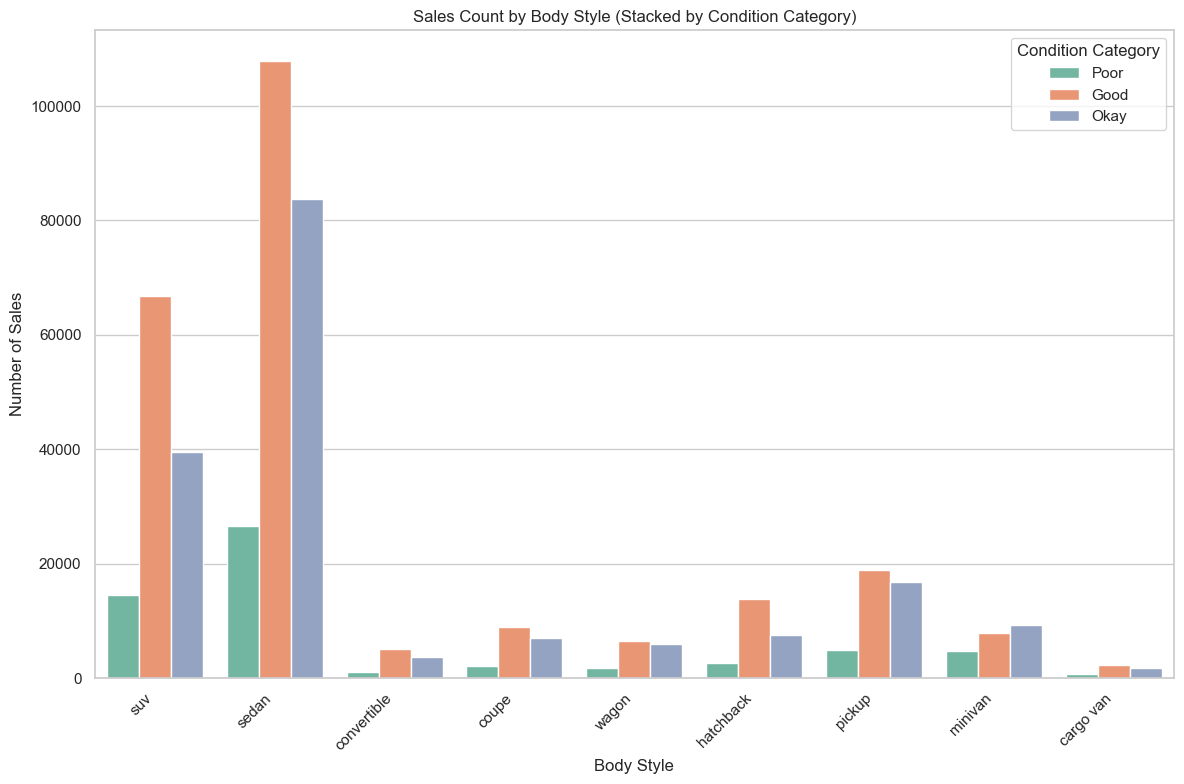

C:\Users\Alpha\AppData\Local\Temp\ipykernel_14680\2913444899.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='state', y='price_gap_pct', palette='husl')


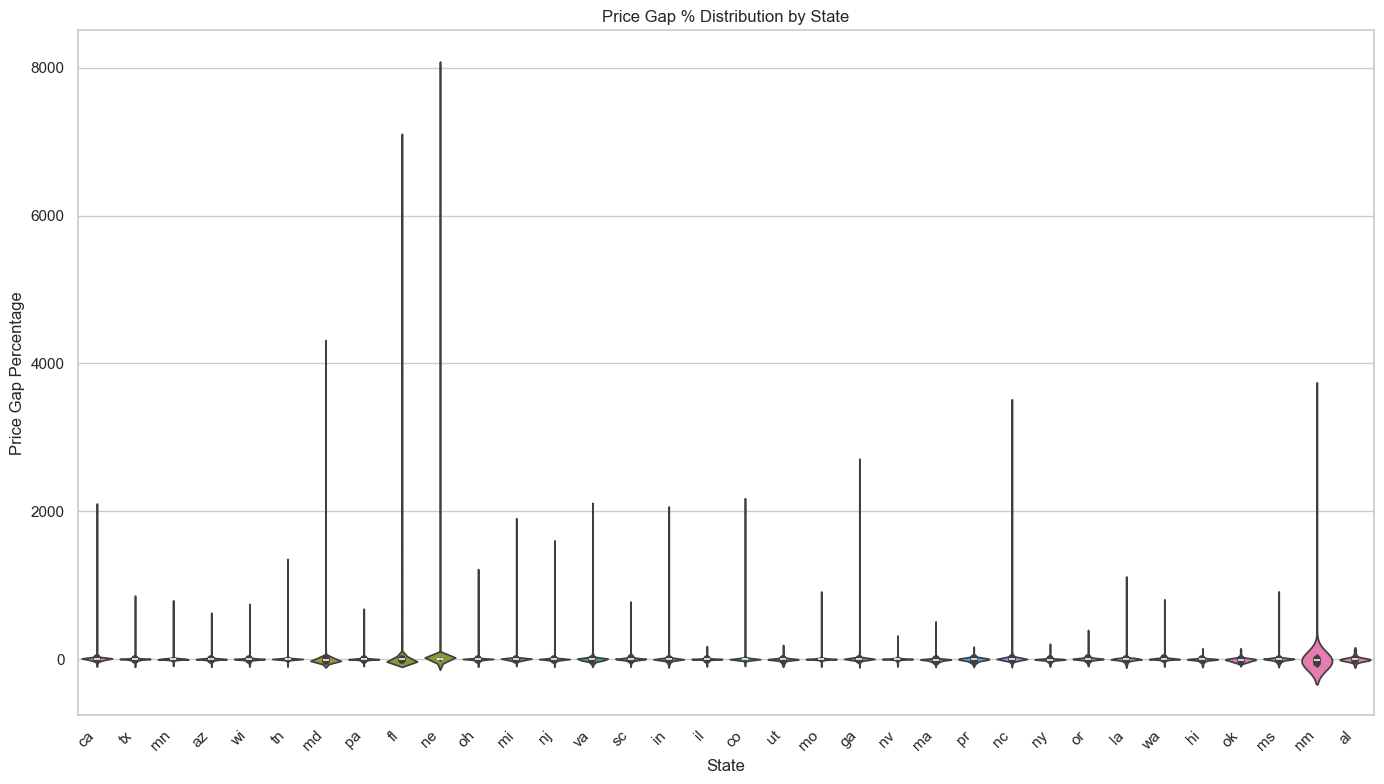

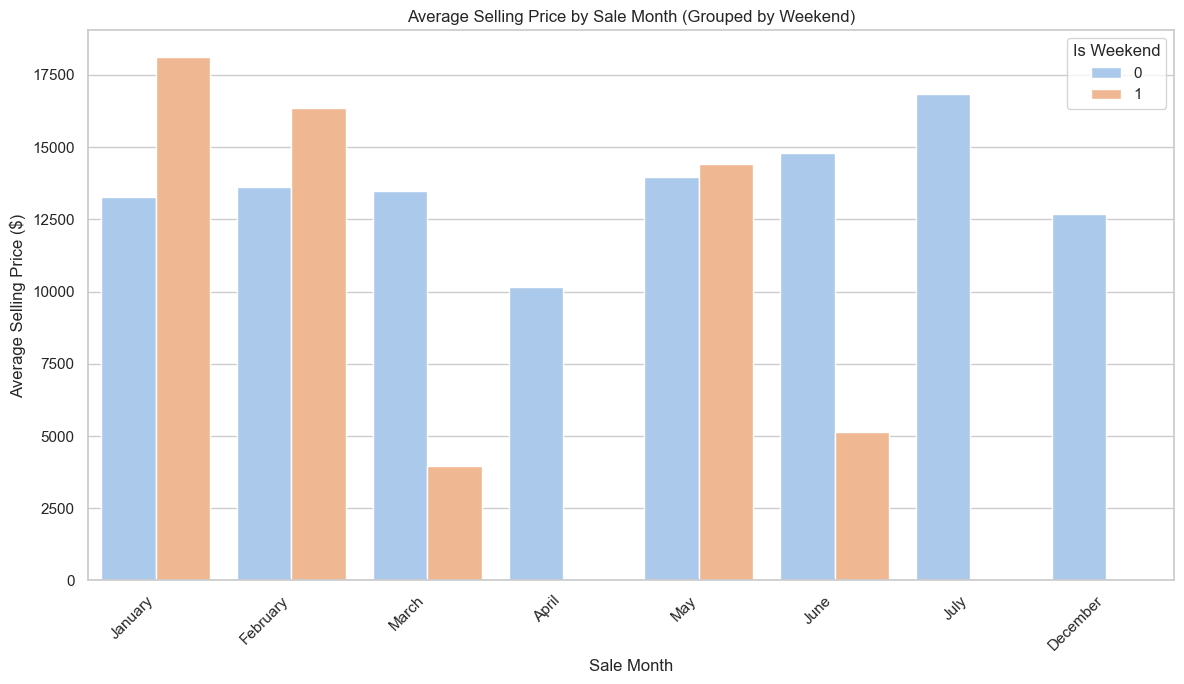

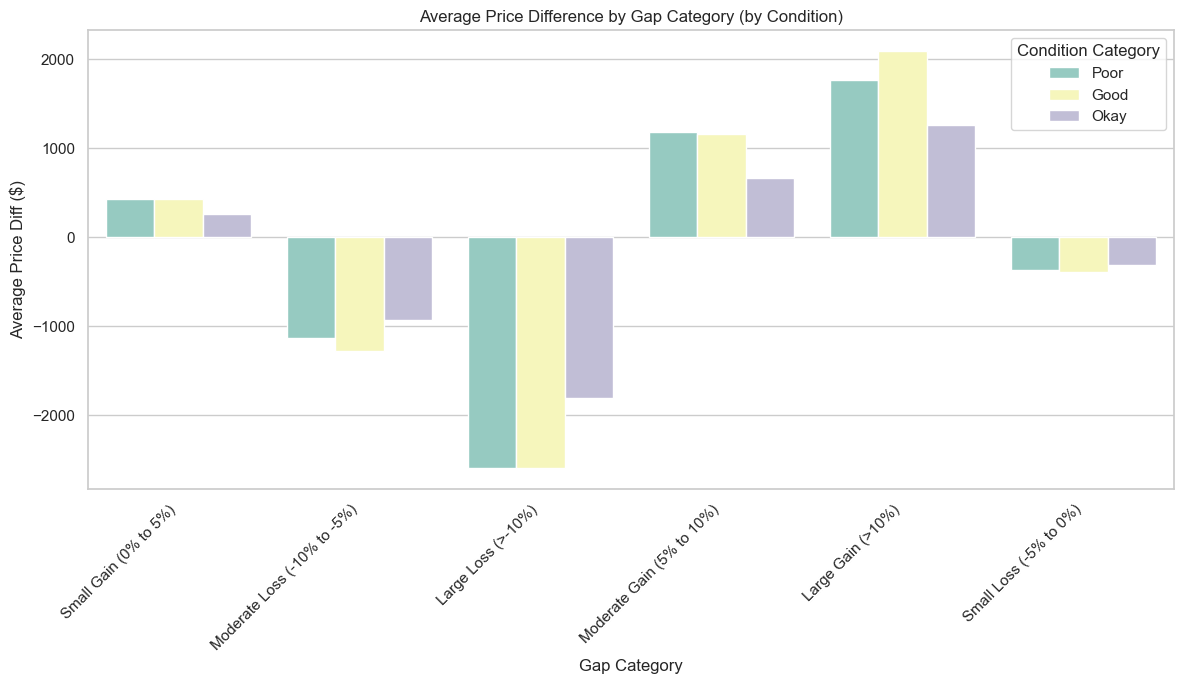

<Figure size 1600x1200 with 0 Axes>

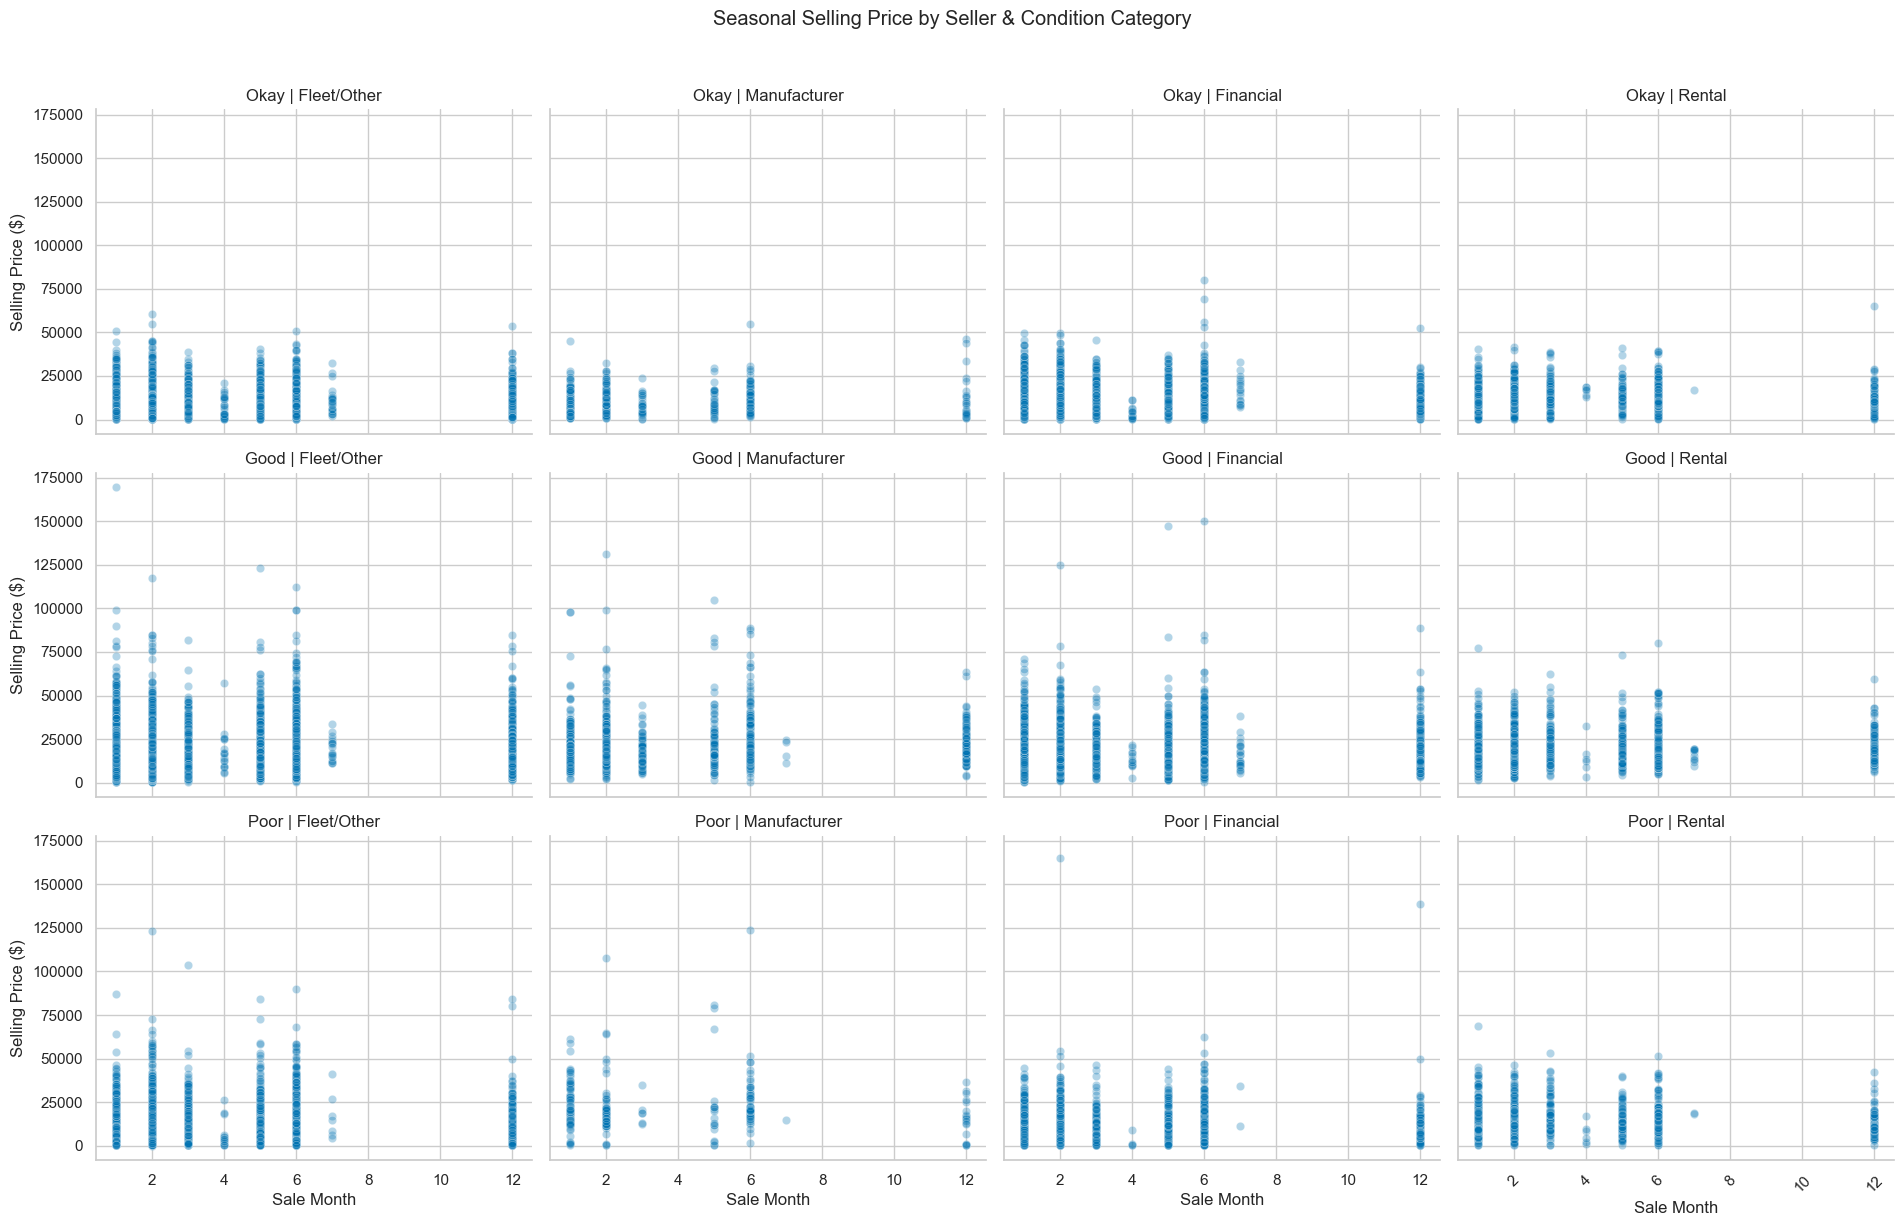

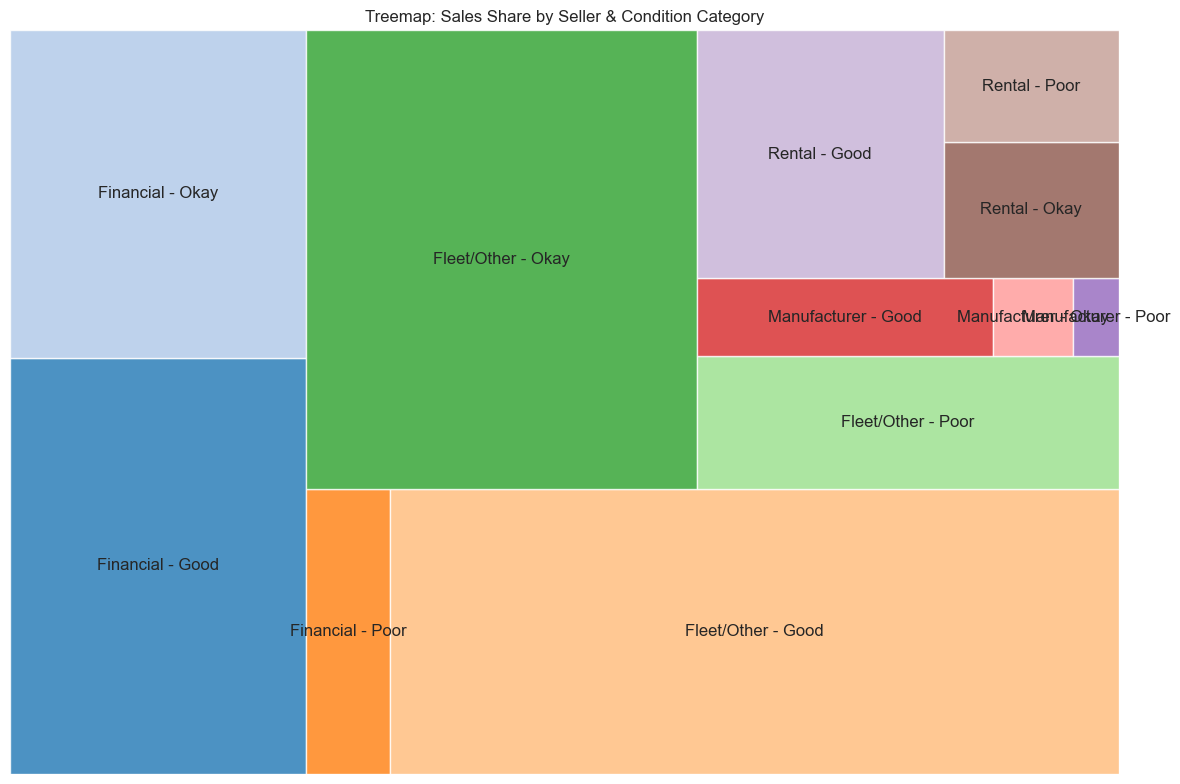

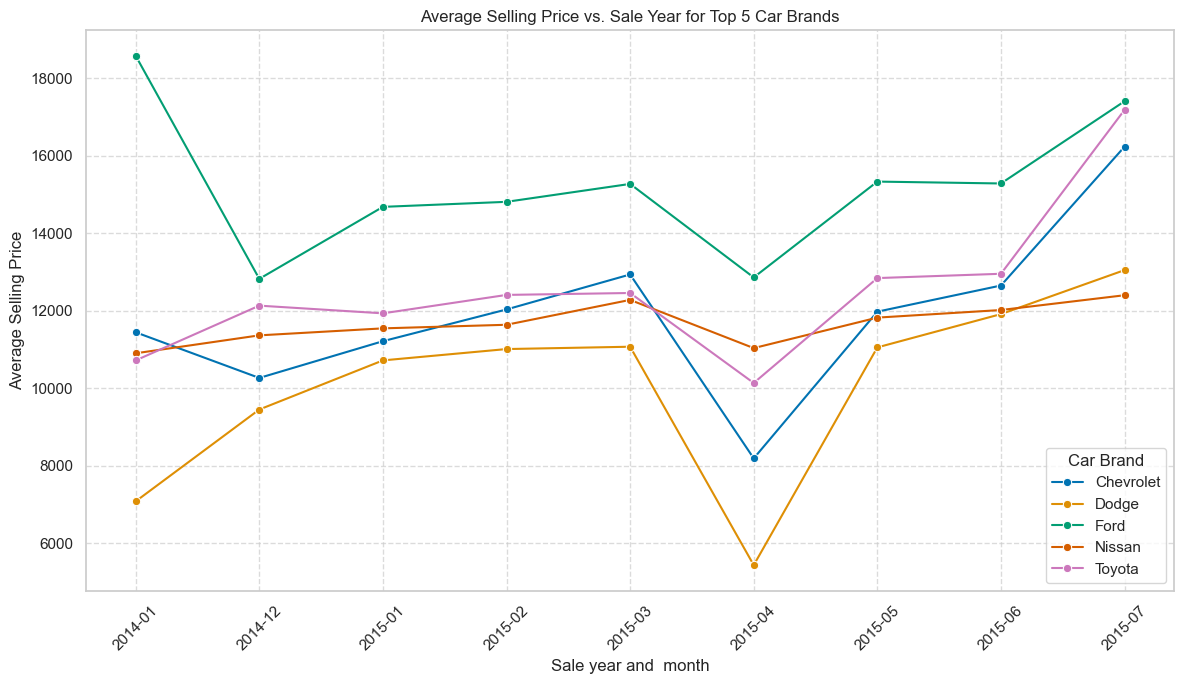

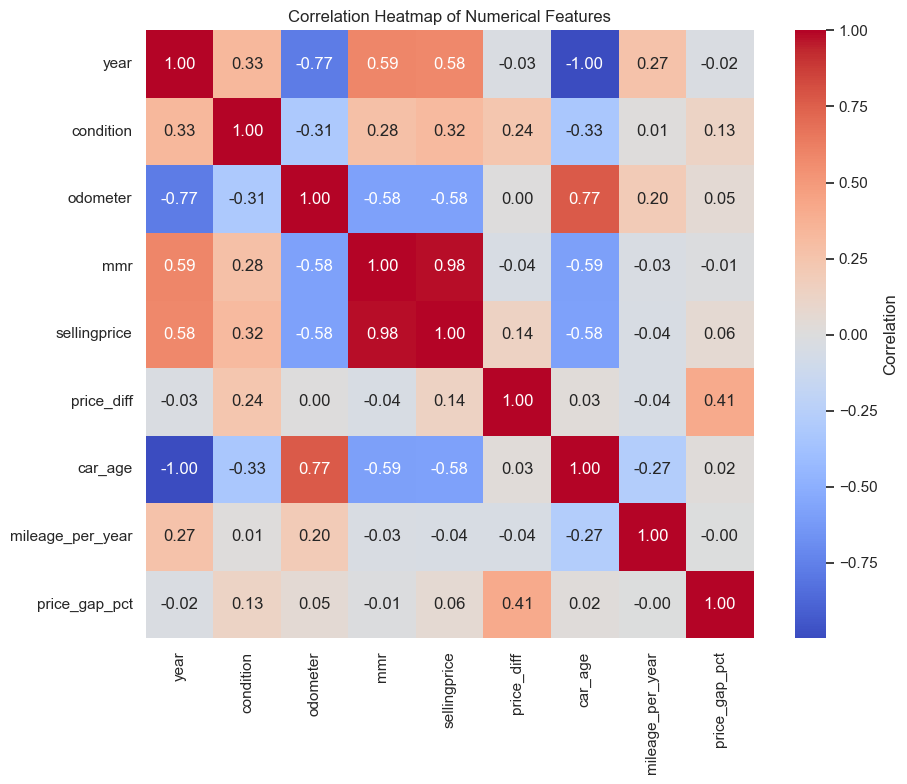

In [90]:

all_makes = df['make'].unique()
n_makes = len(all_makes)
##-------------Distribution and Trend Graphs-----------------##
# 1. target
sns.histplot(df['sellingprice'], bins=50, kde=True)
plt.title('Selling price frequency')
plt.xlabel('Frequency')
plt.ylabel('Selling Price ($)')
plt.show()
print(df['sellingprice'].describe())

# 2. sale year vs selling price

sns.boxplot(x='sale_year', y='sellingprice', data=df)
plt.title('Sale year vs. Selling price')
plt.xlabel('Sale year')
plt.ylabel('Selling Price ($)')
plt.xticks(rotation=90); plt.show()

# 3. sales per brand
makes = df['make'].unique()
make_counts = df['make'].value_counts()

count_by_make = make_counts.reindex(makes).fillna(0).values.tolist()

summary_df = pd.DataFrame({
    'make': makes,
    'sales_count': count_by_make
})


plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='make', y='sales_count')
plt.title('Number of Sales by Make')
plt.xlabel('Make')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. condition vs sellingprice

sns.boxplot(data=df, x='condition_category', y='sellingprice')
plt.title('Number of Sales by Make')
plt.xlabel('Make')
plt.ylabel('Number of Sales')
plt.show()

# 5. seller_category vs sale count

sellers = df['seller_category'].unique()
seller_counts = df['seller_category'].value_counts()

count_by_seller = seller_counts.reindex(sellers).fillna(0).values.tolist()

summary_df = pd.DataFrame({
    'seller': sellers,
    'sales_count': count_by_seller
})


plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x='seller', y='sales_count')
plt.title('Number of Sales by seller type')
plt.xlabel('Seller type')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##-------------Relationship and Correlation Graphs-----------------##
# 1. odometer vs sellingprice: color: transmission
sns.scatterplot(data=df, x='odometer', y='sellingprice', hue='transmission', alpha=.15)
plt.title('Selling Price vs. Odometer by Transmission Type')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Selling Price ($)')
plt.legend(title='Transmission')
plt.show()

# 2. car age vs mileage per year: size: sellingprice
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='car_age', y='mileage_per_year', size='sellingprice', ax=ax)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
plt.title('Car age vs. Mileage per year by Selling price')
plt.xlabel('Car age (Year)')
plt.ylabel('Mileage per year')
plt.show()

# 3. mmr vs selling price
sns.scatterplot(data=df, x='mmr', y='sellingprice', hue='is_luxury')
plt.show()

# 4. seller cat vs odometer: hue: condition
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='seller_category', y='odometer', hue='condition_category', ax=ax)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
plt.show()

##-------------- Categorical Comparison Graphs ------------------##
# 1. number of sales for each body type
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='body', hue='condition_category', palette='Set2')
plt.title('Sales Count by Body Style (Stacked by Condition Category)')
plt.xlabel('Body Style')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition Category')
plt.tight_layout()
plt.show()

# 2. state vs price gap percentage
plt.figure(figsize=(14, 8))
sns.violinplot(data=df, x='state', y='price_gap_pct', palette='husl')
plt.title('Price Gap % Distribution by State')
plt.xlabel('State')
plt.ylabel('Price Gap Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# 3. ave selling price for each month
plt.figure(figsize=(12, 7))
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
unique_months = df['sale_month_name'].unique()
month_order = sorted(unique_months, key=lambda x: month_map.get(x.title(), 6))

sns.barplot(data=df, x='sale_month_name', y='sellingprice', hue='is_weekend', 
            order=month_order, palette='pastel', estimator='mean', errorbar=None)
plt.title('Average Selling Price by Sale Month (Grouped by Weekend)')
plt.xlabel('Sale Month')
plt.ylabel('Average Selling Price ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Is Weekend')
plt.tight_layout()
plt.show()

# 4. price diff for each gap cat
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='gap_category', y='price_diff', hue='condition_category', 
            palette='Set3', estimator='mean', errorbar=None)  # errorbar=None to skip CIs for simplicity
plt.title('Average Price Difference by Gap Category (by Condition)')
plt.xlabel('Gap Category')
plt.ylabel('Average Price Diff ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition Category')
plt.tight_layout()
plt.show()

# 5. selling price per month
plt.figure(figsize=(16, 12))
df_sample = df.sample(50000, random_state=42)  # cap at 50k for facet plot cause large dataset

g = FacetGrid(df_sample, col='seller_category', row='condition_category', 
              height=4, aspect=1.2, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x='sale_month', y='sellingprice', alpha=0.3)
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.set_axis_labels('Sale Month', 'Selling Price ($)')
g.fig.suptitle('Seasonal Selling Price by Seller & Condition Category', y=1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. sales for certain seller cat and condition cat

plt.figure(figsize=(12, 8))

# Compute counts by combo
combo_counts = df.groupby(['seller_category', 'condition_category']).size().reset_index(name='count')

# Flatten labels for treemap
labels = combo_counts['seller_category'] + ' - ' + combo_counts['condition_category']
sizes = combo_counts['count'].values

# Plot treemap
squarify.plot(sizes=sizes, label=labels, alpha=0.8, color=sns.color_palette('tab20', len(labels)))
plt.title('Treemap: Sales Share by Seller & Condition Category')
plt.axis('off')  # Hide axes for clean look
plt.tight_layout()
plt.show()

# 7. trend of sellingprice over 2 years
# get timestamp in form yyyy-mm
df['yyyy-mm'] = df['saledate'].apply(lambda x: x[:7])

#get the selling price trend for top 5 car brands
top_n = 5
top_brands = df['make'].value_counts().head(top_n).index

df_top_brands = df[df['make'].isin(top_brands)].copy()

df['yyyy-mm'] = df['saledate'].apply(lambda x: x[:7])

# Group by sale_year and make, and calculate the mean selling price
aggregated_data = df_top_brands.groupby(['yyyy-mm', 'make'])['sellingprice'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='yyyy-mm', y='sellingprice', hue='make', data=aggregated_data, marker='o')
plt.title(f'Average Selling Price vs. Sale Year for Top {top_n} Car Brands')
plt.xlabel('Sale year and  month')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Car Brand')
plt.tight_layout()
plt.show()

# 8. correlation
num_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice', 'price_diff', 
            'car_age', 'mileage_per_year', 'price_gap_pct']  # Adjust as needed
df_num = df[num_cols]  # Drop rows with NaNs for clean corr

plt.figure(figsize=(10, 8))
corr_matrix = df_num.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()